In [ ]:

!pip install -q lightgbm tqdm
import nltk
nltk.download('vader_lexicon')


import pandas as pd
import numpy as np
from tqdm import tqdm
import lightgbm as lgb
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch

# Check GPU
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Load dataset
file_path = '/content/drive/MyDrive/review-South_Carolina_10.json'  # 🔁 update path if needed


# Load JSONL and select required columns
with open(file_path, 'r') as f:
    data = [json.loads(line) for line in f]

df = pd.DataFrame(data)

# Check and handle missing columns
expected_cols = {'user_id', 'gmap_id', 'rating', 'time', 'text'}
missing = expected_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing columns in dataset: {missing}")

df['text'] = df['text'].fillna('')

# VADER Sentiment Analysis
sia = SentimentIntensityAnalyzer()

def vader_sentiment_batch(texts, batch_size=10000):
    sentiments = []
    for i in tqdm(range(0, len(texts), batch_size), desc="VADER Sentiment", ncols=100):
        batch = texts[i:i+batch_size]
        scores = [sia.polarity_scores(text)['compound'] for text in batch]
        sentiments.extend(scores)
    return sentiments

df['vader_sentiment'] = vader_sentiment_batch(df['text'].tolist())

# Time features
df['time'] = pd.to_datetime(df['time'], unit='ms', errors='coerce')
df['hour'] = df['time'].dt.hour
df['weekday'] = df['time'].dt.weekday
df['month'] = df['time'].dt.month

def time_of_day(hour):
    if pd.isna(hour):
        return 'unknown'
    if 5 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 17:
        return 'afternoon'
    elif 17 <= hour < 21:
        return 'evening'
    else:
        return 'night'

df['time_of_day'] = df['hour'].apply(time_of_day).astype('category')
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)
latest_time = df['time'].max()
df['days_since_review'] = (latest_time - df['time']).dt.days

# Encode IDs
df['user_id'] = df['user_id'].astype('category')
df['gmap_id'] = df['gmap_id'].astype('category')

# Define features for LightGBM
features = [
    'user_id', 'gmap_id', 'hour', 'weekday', 'month',
    'is_weekend', 'time_of_day', 'days_since_review', 'vader_sentiment'
]

X = df[features]
y = df['rating']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train LightGBM
train_data = lgb.Dataset(
    X_train, label=y_train,
    categorical_feature=['user_id', 'gmap_id', 'time_of_day']
)
test_data = lgb.Dataset(
    X_test, label=y_test,
    reference=train_data,
    categorical_feature=['user_id', 'gmap_id', 'time_of_day']
)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.03,
    'num_leaves': 31,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'verbosity': -1
}

print("Training LightGBM...")
evals_result = {}



[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


CUDA Available: True
GPU: NVIDIA A100-SXM4-40GB


VADER Sentiment: 100%|████████████████████████████████████████████| 651/651 [11:19<00:00,  1.04s/it]


📈 Training LightGBM...


TypeError: train() got an unexpected keyword argument 'early_stopping_rounds'

Training until validation scores don't improve for 10 rounds
[10]	training's rmse: 1.04068	valid_1's rmse: 1.0388
[20]	training's rmse: 1.00775	valid_1's rmse: 1.00633
[30]	training's rmse: 0.987435	valid_1's rmse: 0.986442
[40]	training's rmse: 0.972614	valid_1's rmse: 0.971972
[50]	training's rmse: 0.960161	valid_1's rmse: 0.959859
[60]	training's rmse: 0.95193	valid_1's rmse: 0.951966
[70]	training's rmse: 0.94777	valid_1's rmse: 0.948086
[80]	training's rmse: 0.943239	valid_1's rmse: 0.943865
[90]	training's rmse: 0.939915	valid_1's rmse: 0.940793
[100]	training's rmse: 0.937575	valid_1's rmse: 0.938713
Did not meet early stopping. Best iteration is:
[100]	training's rmse: 0.937575	valid_1's rmse: 0.938713

✅ Test RMSE: 0.9387


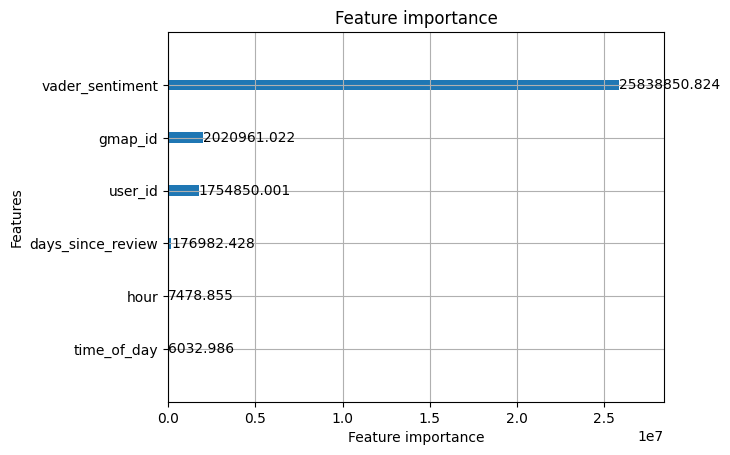

In [ ]:
model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, test_data],
    num_boost_round=100,
    callbacks=[
        lgb.early_stopping(stopping_rounds=10),
        lgb.log_evaluation(period=10)
    ]
)



# Evaluate
y_pred = model.predict(X_test)
rmse = np.sqrt(np.mean((y_test - y_pred)**2))
print(f"\nTest RMSE: {rmse:.4f}")

#  Feature importance
lgb.plot_importance(model, max_num_features=15, importance_type='gain')
plt.show()